In [ ]:
!pip install fastf1
!pip install gurobipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 125.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.2/70.2 kB 200.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 63.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 120.0 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 109.9 kB/s eta 0:00:00


### **Initial Setup and Data Preprocessing**

*Data Set*

FastF1 is an open-source python package that allows anyone to view and analyze Formula 1 data. It gathers it's information directly from Formula 1 official live timing system and historical data.


*Tire Inventory Creation*

Our first step was create a tire inventory by using the FastF1 API to go through each practice session and qualifying to determine what was used. The reason why we had to do this was because FastF1 doesn't explicitly outline what each driver has in there garage for the race session. Each driver starts the beginning of the race weekend with 8 soft tires, 3 medium tires, and 3 hard tires. They also must have at least 7 tires for the race, therefore we created a dictionary that only selects their youngest 7 tires, which is what the predictive model can choose from in the race. We use FastF1's built in functions to select our specific drivers from our list ".pick_driver",


*Data Cleaning*

Next, we have to clean the data by first removing laps that that was an 'in' or 'out' lap (in or out of the pitlane), as well as any laps with a safety car or virtual safety car. This is done through FastF1's function ".pick_accurate". We chose the specific data that we need from the FastF1 set which is "LapNumber", "LapTime", "Compound", and "TyreLife". Another step we added was to remove any statistical outliers, which is anything slower than 107% of the drivers fastest time in order to create a better prediction.


In [ ]:
import fastf1
import pandas as pd
import os

# creates the cache to store the FastF1 data
os.makedirs('cache', exist_ok=True)
fastf1.Cache.enable_cache('cache')

year = 2025
track = 'Montreal'
drivers = ['ANT', 'RUS']
df_list = []

# Tire Inventory for Race based on what was used in 3 practice sessions + qualifying
def tire_inventory(year, track, driver):
    base_allocation = {'SOFT': 8, 'MEDIUM': 3, 'HARD': 2}
    used_tires = {'SOFT': [], 'MEDIUM': [], 'HARD': []}

    for s_name in ['FP1', 'FP2', 'FP3', 'Q']:
        try:
            session = fastf1.get_session(year, track, s_name)
            session.load(telemetry=False, weather=False)
            laps = session.laps.pick_driver(driver).dropna(subset=['Compound', 'TyreLife'])
            for stint, group in laps.groupby('Stint'):
                c = group['Compound'].iloc[0].upper()
                max_age = int(group['TyreLife'].max())
                if c in used_tires:
                    used_tires[c].append(max_age)
        except Exception as e:
            print(f"  Warning: Could not load {s_name} for {driver}: {e}")

#creating the available sets list
    available_sets = []
    for c in ['SOFT', 'MEDIUM', 'HARD']:
        num_available = base_allocation[c] - len(used_tires[c])
        for _ in range(max(0, num_available)):
            available_sets.append({'Compound': c, 'Age': 0})
        for age in used_tires[c]:
            available_sets.append({'Compound': c, 'Age': age})

    available_sets = sorted(available_sets, key=lambda x: x['Age'])[:7]

    estimated_inventory = {'SOFT': {}, 'MEDIUM': {}, 'HARD': {}}
    for t in available_sets:
        c = t['Compound']
        a = t['Age']
        if a not in estimated_inventory[c]:
            estimated_inventory[c][a] = 0
        estimated_inventory[c][a] += 1

    return estimated_inventory

print("Race Inventory based on Practice and Qualifying Sessions")
inventory = {d: tire_inventory(year, track, d) for d in drivers}
print(inventory)

race_session = fastf1.get_session(year, track, 'R')
race_session.load()

#data cleaning
df_list = []
#for each driver:
for d in drivers:
    #cleaning Part 1: remove laps that they pitted on, safety cars, yellow flags
    clean_laps = race_session.laps.pick_drivers(d).pick_accurate()
    #get the four types of data
    df_driver = clean_laps[['LapNumber', 'LapTime', 'Compound', 'TyreLife']].copy()
    df_driver['Driver'] = d
    # ensure time to seconds
    df_driver['LapTime_sec'] = df_driver['LapTime'].dt.total_seconds()

    #cleaning Part 2: remove laps that are statistical outliers (greater than 107% of fastest time)
    fastest_lap = df_driver['LapTime_sec'].min()
    cutoff_time = fastest_lap * 1.07
    df_driver = df_driver[df_driver['LapTime_sec'] <= cutoff_time]
    df_list.append(df_driver)

#combine both drivers into one dataframe
df_race = pd.concat(df_list, ignore_index=True)
df_race = df_race.dropna(subset=['LapTime_sec'])

print(df_race.head())

Race Inventory based on Practice and Qualifying Sessions


events      WARNING 	Correcting user input 'Montreal' to 'Canadian Grand Prix'
core           INFO 	Loading data for Canadian Grand Prix - Practice 1 [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Practice 1 [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_

{'ANT': {'SOFT': {1: 1, 3: 3}, 'MEDIUM': {3: 1}, 'HARD': {0: 1, 1: 1}}, 'RUS': {'SOFT': {3: 3}, 'MEDIUM': {3: 2}, 'HARD': {0: 1, 1: 1}}}


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
INFO:fastf1.api:Fetching lap count data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for track_status_data. Loading data...
_api

   LapNumber                LapTime Compound  TyreLife Driver  LapTime_sec
0        2.0 0 days 00:01:16.584000   MEDIUM       8.0    ANT       76.584
1        3.0 0 days 00:01:16.878000   MEDIUM       9.0    ANT       76.878
2        4.0 0 days 00:01:16.357000   MEDIUM      10.0    ANT       76.357
3        5.0 0 days 00:01:16.186000   MEDIUM      11.0    ANT       76.186
4        6.0 0 days 00:01:16.159000   MEDIUM      12.0    ANT       76.159


### **Predictive Modeling:**

***Data Preparation and Global OLS Validation***

In order to predict the tire degradation, we created the dummy variables for the "Compound" data points and connected "TyreLife" to the compound. We also had to create a OLS regression from just Montreal race data to ensure our approach was in the right direction. We included "LapNumber" in order to help account for full race effects like fuel burn (decrease in weight of car) and track evolution. We then tested the models out-of-sample accuracy using the metrics we learned in class: R^2, RMSE, and MAPE.

***Cross-Race Panel Regression***

Initially during our first iterations, we only used data from the Montreal Grand Prix; however there was perfect multicollinearity for "TyreLife" and "LapNumber" as they increase the same rate (+1 per lap) during a stint. It was absorbing the improved lap times from the fuel burn into the tire wear, and we were recieving a negative degradation slope. This meant that it was predicted that our tires were getting faster throughout a stint, which isn't possible. To fix this, we increased our scope, loading all races prior to Montreal (8 tracks: Australia, Japan, China, Bahrain, Saudi Arabia, Miami, Emilia Romagna, Monaco). We cleaned this data by setting a minimum stint to be 4 laps to filter out noise. This fixed the collinearity issue we had, as the same tire age was appearing at multiple tracks on different lap numbers. We then fit a panel  OLS regression for each driver using "TyreLife", "Compound", "LapNumber" and the race effects from fuel and track evolution.

***Setting the Baseline and Fallbacks***

With our new solution using multiple races to create the degradation slopes, we had to anchor that base lap time back to the Montreal circuit in order for the pace to be realistic. We do this as each track is different in terms of length, speed, and tire degradation, so we set the intercept to be the Montreal circuit. Another issue that occured was sparse data on certain tire compounds, there was no intercept for it. In order to not hardcode our assumption, the fallback uses the median slope for drivers for the compound.

***Expected Lap Time Generation***

We then iterate through the 70 laps, all compounds, and tire ages to generate the "expected_lap_time" dictionary. This shows the exact project lap time in seconds for each possible combination, which our optimization section then uses to determine the best possible race strategy.

core           INFO 	Loading data for Australian Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Race [v3.8.2]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...


                            OLS Regression Results                            
Dep. Variable:            LapTime_sec   R-squared:                       0.886
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     155.8
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           6.28e-37
Time:                        03:13:01   Log-Likelihood:                 7.6341
No. Observations:                  85   AIC:                            -5.268
Df Residuals:                      80   BIC:                             6.945
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const               

req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

  2025 China...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

...

  2025 Emilia Romagna...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F

  2025 Monaco...


req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
INFO:fastf1.api:Fetching session status data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
INFO:fastf1.fastf1.req:No cached data found for lap_count. Loading data...
_api           INFO 	F


Panel dataset: 603 laps across 8 race(s), 2 driver(s), 4 compound(s).


--- Panel OLS: ANT ---
                            OLS Regression Results                            
Dep. Variable:            LapTime_sec   R-squared:                       0.992
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     3059.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):          3.63e-290
Time:                        03:14:27   Log-Likelihood:                -276.58
No. Observations:                 299   AIC:                             577.2
Df Residuals:                     287   BIC:                             621.6
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------

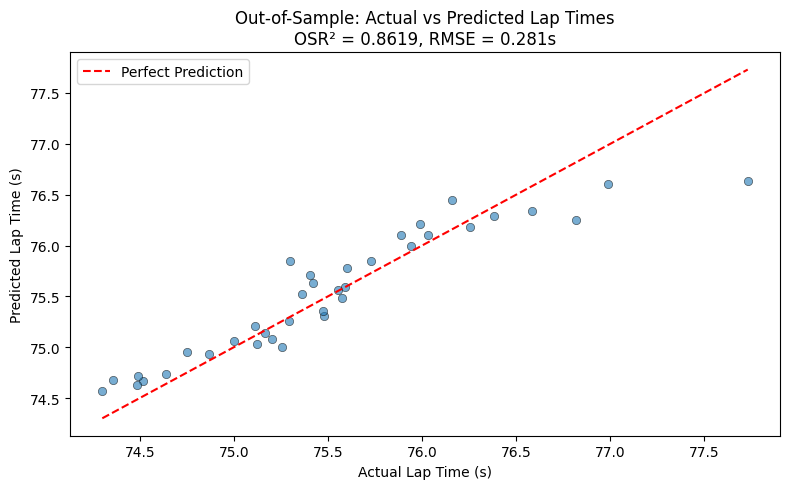

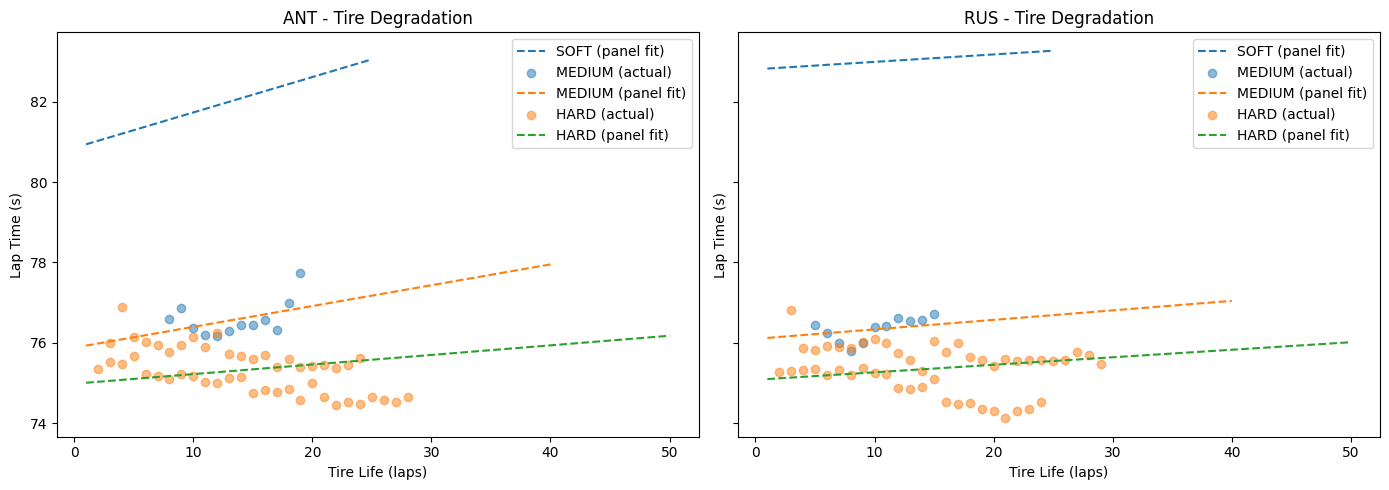

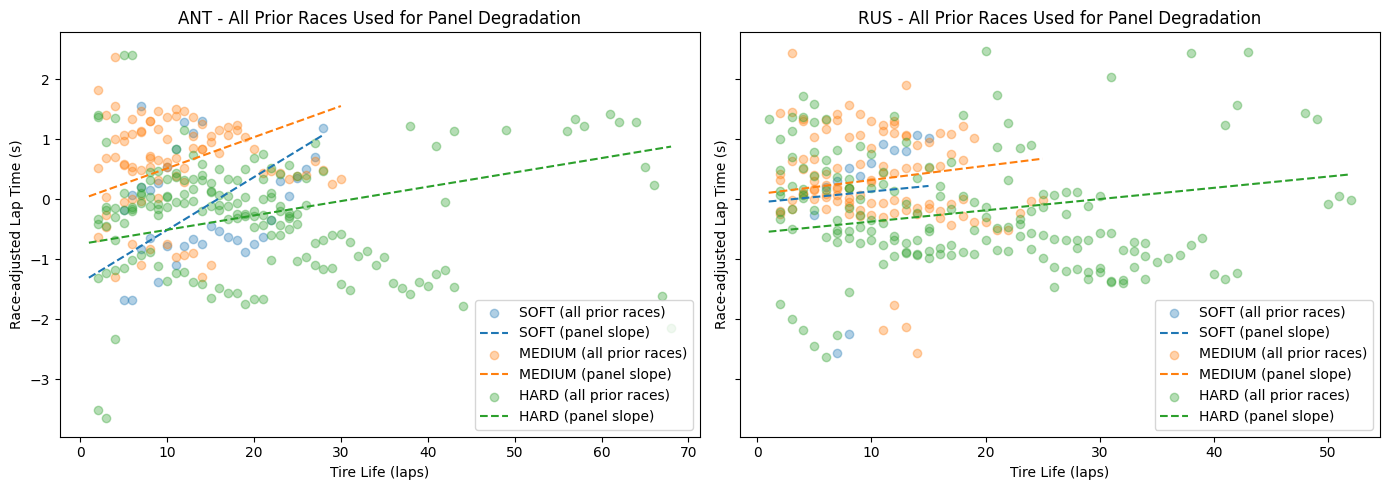

ANT SOFT base = 80.85480673374586 | degradation = 0.08817142807133158
ANT MEDIUM base = 75.87842101946016 | degradation = 0.05186387510171658
ANT HARD base = 74.98117183852959 | degradation = 0.023892563977278625
RUS SOFT base = 82.81091800620416 | degradation = 0.018527239890800268
RUS MEDIUM base = 76.09833527761198 | degradation = 0.023657381329711267
RUS HARD base = 75.0781096471958 | degradation = 0.018724374336812594


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings("ignore")

#Data Cleaning
df_model = df_race[['TyreLife', 'LapNumber', 'Compound', 'Driver', 'LapTime_sec']].copy()

#Create dummy variables for Compound
df_model = pd.get_dummies(df_model, columns=['Compound'], drop_first=True)

for col in df_model.columns:
    if df_model[col].dtype == 'bool':
        df_model[col] = df_model[col].astype(int)

# Create interaction between TyreLife and compound dummy
compound_dummies = [col for col in df_model.columns if col.startswith('Compound_')]
for col in compound_dummies:
    df_model[f'TyreLife_x_{col}'] = df_model['TyreLife'] * df_model[col]

#OLS for Montreal
y = df_model['LapTime_sec']

feature_cols = (['TyreLife', 'LapNumber'] + compound_dummies + [col for col in df_model.columns if col.startswith('TyreLife_x_')])

X = df_model[feature_cols]
X = sm.add_constant(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

ols_model = sm.OLS(y_train, X_train).fit()
print(ols_model.summary())

# Out-of-sample validation
y_pred_test = ols_model.predict(X_test)

OSR2 = 1 - np.sum((y_pred_test - y_test) ** 2) / np.sum((y_test - np.mean(y_test)) ** 2)
RMSE = np.sqrt(np.mean((y_pred_test - y_test) ** 2))
MAPE = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

print(f"\n--- Out-of-Sample Validation ---")
print(f"In-sample R²:       {ols_model.rsquared:.4f}")
print(f"Out-of-sample R²:   {OSR2:.4f}")
print(f"RMSE:               {RMSE:.4f} seconds")
print(f"MAPE:               {MAPE:.2f}%")

#Panel regression for degradation curves
prior_races = [(2025, 'Australia'),(2025, 'China'),(2025, 'Japan'),(2025, 'Bahrain'),(2025, 'Saudi Arabia'),(2025, 'Miami'),(2025, 'Emilia Romagna'),(2025, 'Monaco')]

MIN_LAPS = 4   # minimum laps on a compound to include a driver's stint

drivers   = ['ANT', 'RUS']
compounds = ['SOFT', 'MEDIUM', 'HARD']


def load_prior_race_laps(year, track, driver_list, min_laps):
    #load sessions one at a time
    try:
        session = fastf1.get_session(year, track, 'R')
        session.load(telemetry=False, weather=False)
    except Exception as e:
        print(f"  Could not load {year} {track}: {e}")
        return None

    race_records = []
    for d in driver_list:
        driver_laps = (session.laps.pick_drivers(d).pick_accurate()[['LapNumber', 'LapTime', 'Compound', 'TyreLife']].copy())
        driver_laps['LapTime_sec'] = driver_laps['LapTime'].dt.total_seconds()
        driver_laps = driver_laps.dropna(subset=['LapTime_sec', 'Compound', 'TyreLife'])

        if driver_laps.empty:
            continue

        #outlier filter of 107% of driver's fastest lap
        fastest = driver_laps['LapTime_sec'].min()
        driver_laps = driver_laps[driver_laps['LapTime_sec'] <= fastest * 1.07]

        #only keep compounds that appear at least min_laps times
        compound_counts = driver_laps['Compound'].value_counts()
        valid_compounds  = compound_counts[compound_counts >= min_laps].index
        driver_laps      = driver_laps[driver_laps['Compound'].isin(valid_compounds)]

        if driver_laps.empty:
            continue

        driver_laps['Driver'] = d
        driver_laps['Race']   = f"{year}_{track.replace(' ', '_')}"
        race_records.append(driver_laps[['LapNumber', 'LapTime_sec', 'Compound', 'TyreLife', 'Driver', 'Race']])

    return pd.concat(race_records, ignore_index=True) if race_records else None


#Load all prior races to montreal
prior_laps_list = []

for year, track in prior_races:
    print(f"  {year} {track}...")
    df_prior = load_prior_race_laps(year, track, drivers, MIN_LAPS)
    if df_prior is not None and not df_prior.empty:
        prior_laps_list.append(df_prior)

df_panel = pd.concat(prior_laps_list, ignore_index=True)
print(
    f"\nPanel dataset: {len(df_panel)} laps across "
    f"{df_panel['Race'].nunique()} race(s), "
    f"{df_panel['Driver'].nunique()} driver(s), "
    f"{df_panel['Compound'].nunique()} compound(s).\n"
)

#Fit panel OLS for driver across prior races returning a dictionary
def fit_panel_degradation(df_panel_driver, driver_label):
    df = df_panel_driver.copy()

    #Compound dummies with hard compound as baseline so its slope is the raw TyreLife coeffiecient
    df['is_MEDIUM'] = (df['Compound'] == 'MEDIUM').astype(int)
    df['is_SOFT']   = (df['Compound'] == 'SOFT').astype(int)

    #TyreLife interaction terms
    df['TyreLife_x_MEDIUM'] = df['TyreLife'] * df['is_MEDIUM']
    df['TyreLife_x_SOFT']   = df['TyreLife'] * df['is_SOFT']

    #Race fixed effects (drop one race as baseline to avoid multicollinearity)
    race_dummies = pd.get_dummies(df['Race'], drop_first=True, prefix='Race').astype(int)
    df = pd.concat([df, race_dummies], axis=1)
    race_cols = [c for c in df.columns if c.startswith('Race_')]

    feature_cols = (['TyreLife', 'TyreLife_x_MEDIUM', 'TyreLife_x_SOFT', 'LapNumber'] + race_cols)

    X = sm.add_constant(df[feature_cols])
    y = df['LapTime_sec']

    model = sm.OLS(y, X).fit()
    print(f"\n--- Panel OLS: {driver_label} ---")
    print(model.summary())

    hard_slope   = model.params['TyreLife']
    medium_slope = model.params['TyreLife'] + model.params.get('TyreLife_x_MEDIUM', 0)
    soft_slope   = model.params['TyreLife'] + model.params.get('TyreLife_x_SOFT',   0)

    slopes = {'HARD': hard_slope, 'MEDIUM': medium_slope, 'SOFT': soft_slope}

    for c, s in slopes.items():
        print(f"  {c}: raw panel slope = {s:.5f} s/lap")

    return slopes


#Fit panel model for each driver
panel_degradation = {}

for d in drivers:
    df_d = df_panel[df_panel['Driver'] == d].copy()
    if df_d.empty:
        print(f"  {d}: no panel data available.")
        panel_degradation[d] = {}
        continue
    panel_degradation[d] = fit_panel_degradation(df_d, d)

#Compound-level medians as a fallback
compound_slope_pool = {c: [] for c in compounds}
for d in drivers:
    for c in compounds:
        if c in panel_degradation[d] and not np.isnan(panel_degradation[d][c]):
            compound_slope_pool[c].append(panel_degradation[d][c])

compound_median_slope = {}
for c in compounds:
    positive_slopes = [s for s in compound_slope_pool[c] if s > 0]
    compound_median_slope[c] = np.median(positive_slopes) if positive_slopes else None
    print(f"\nCompound {c}: median slope across all drivers = "
          f"{compound_median_slope[c]:.5f} s/lap "
          f"(from {len(positive_slopes)} positive observation(s))")

#Base lap time (intercept) anchored to Montreal race data.
#Formula: lap[d][c] = mean(Montreal LapTime_sec) - degradation[d][c] * mean(TyreLife)
lap         = {}
degradation = {}

for d in drivers:
    lap[d]         = {}
    degradation[d] = {}

    driver_data = df_race[df_race['Driver'] == d].copy()

    for c in compounds:
        #Degradation slope from panel regression
        raw_slope = panel_degradation.get(d, {}).get(c)

        if raw_slope is None or np.isnan(raw_slope):
            #No panel estimate then use data-driven compound median
            raw_slope = compound_median_slope.get(c)
            if raw_slope is None:
                print(f"{d} - {c}: no panel slope and no compound median available — skipping")
                continue
            print(f"{d} - {c}: degradation from compound-level median (no driver-specific data)")

        #Non-negative constraint so there tire wear cannot make the driver faster
        if raw_slope < 0:
            fallback = compound_median_slope.get(c)
            print(
                f"{d} - {c}: panel slope negative ({raw_slope:.5f}), "
                f"replacing with compound median ({fallback:.5f})"
            )
            raw_slope = fallback if fallback is not None else 0.0

        degradation[d][c] = raw_slope

        #Base lap time anchored to Montreal
        compound_data = driver_data[driver_data['Compound'] == c].copy()

        if len(compound_data) < 3:
            continue

        mean_laptime  = compound_data['LapTime_sec'].mean()
        mean_tyrelife = compound_data['TyreLife'].mean()
        lap[d][c]     = mean_laptime - degradation[d][c] * mean_tyrelife

        print(
            f"\n{d} - {c}: "
            f"lap = {lap[d][c]:.3f}s, "
            f"degradation = {degradation[d][c]:.5f} s/lap "
            f"(slope: panel regression | base: Montreal)"
        )

#Fallback for missing data
for d in drivers:
    for c in compounds:
        if c not in lap[d] and c in degradation[d]:
            #Rank observed compounds to find the closest reference
            observed = {rc: lap[d][rc] for rc in compounds if rc in lap[d]}
            if observed:
                #Adjust reference intercept by the gap in cross-race base pace
                cross_race_mean = {}
                for rc in compounds:
                    subset = df_panel[(df_panel['Driver'] == d) & (df_panel['Compound'] == rc)]
                    if not subset.empty:
                        cross_race_mean[rc] = subset['LapTime_sec'].mean()

                ref_c = next(iter(observed))   # closest available observed compound
                if c in cross_race_mean and ref_c in cross_race_mean:
                    cross_race_offset = cross_race_mean[c] - cross_race_mean[ref_c]
                    lap[d][c] = observed[ref_c] + cross_race_offset
                else:
                    #If cross-race mean is also unavailable use same base as reference
                    lap[d][c] = observed[ref_c]
            else:
                #No observed use of compound at all, then use Montreal overall mean as anchor
                lap[d][c] = df_race[df_race['Driver'] == d]['LapTime_sec'].mean()

            print(f"{d} - {c}: base lap fallback = {lap[d][c]:.3f}s (too few Montreal laps)")

#Plotting
#Out-of-sample validation plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred_test, alpha=0.6, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Lap Time (s)')
plt.ylabel('Predicted Lap Time (s)')
plt.title(f'Out-of-Sample: Actual vs Predicted Lap Times\nOSR² = {OSR2:.4f}, RMSE = {RMSE:.3f}s')
plt.legend()
plt.tight_layout()
plt.show()

#Tire degradation curves used for optimization
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, d in enumerate(drivers):
    ax = axes[idx]
    driver_data = df_race[df_race['Driver'] == d]

    for c in compounds:
        cdata = driver_data[driver_data['Compound'] == c]

        if len(cdata) > 0:
            ax.scatter(cdata['TyreLife'], cdata['LapTime_sec'], alpha=0.5, label=f'{c} (actual)')

        if c in lap[d] and c in degradation[d]:
            max_life = {'SOFT': 25, 'MEDIUM': 40, 'HARD': 50}
            t_range  = np.arange(1, max_life[c] + 1)
            ax.plot(t_range, lap[d][c] + degradation[d][c] * t_range, '--', label=f'{c} (panel fit)')

    ax.set_xlabel('Tire Life (laps)')
    ax.set_ylabel('Lap Time (s)')
    ax.set_title(f'{d} - Tire Degradation')
    ax.legend()

fig.tight_layout()
plt.show()

#Prior Race Data from regression for degredation
df_panel_plot = df_panel.copy()

#Adjust lap times within each driver-race section
df_panel_plot['LapTime_adj'] = (df_panel_plot['LapTime_sec'] - df_panel_plot.groupby(['Driver', 'Race'])['LapTime_sec'].transform('mean'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, d in enumerate(drivers):
    ax = axes[idx]
    ddata = df_panel_plot[df_panel_plot['Driver'] == d].copy()

    for c in compounds:
        cdata = ddata[ddata['Compound'] == c].copy()

        if len(cdata) == 0 or c not in degradation[d]:
            continue

        #Scatter all prior-race data points used in the panel model
        ax.scatter(cdata['TyreLife'], cdata['LapTime_adj'], alpha=0.35, label=f'{c} (all prior races)')

        #Anchor fitted line to the adjusted panel data for that driver-compound
        anchor = cdata['LapTime_adj'].mean() - degradation[d][c] * cdata['TyreLife'].mean()

        t_range = np.arange(1, int(cdata['TyreLife'].max()) + 1)

        ax.plot(t_range, anchor + degradation[d][c] * t_range, '--', label=f'{c} (panel slope)')

    ax.set_xlabel('Tire Life (laps)')
    ax.set_ylabel('Race-adjusted Lap Time (s)')
    ax.set_title(f'{d} - All Prior Races Used for Panel Degradation')
    ax.legend()

fig.tight_layout()
plt.show()

#Expected lap times
L       = 70
max_age = 71

expected_lap_time = {d: {i: {c: {} for c in compounds} for i in range(1, L + 1)} for d in drivers}

for d in drivers:
    for i in range(1, L + 1):
        for c in compounds:
            for a in range(1, max_age):
                expected_lap_time[d][i][c][a] = lap[d][c] + degradation[d][c] * a

for d in drivers:
    for c in compounds:
        print(d, c, "base =", lap[d][c], "| degradation =", degradation[d][c])


### **Optimization:**

***Model Initialization and Decision Variables***

For this we construct a mixed-integer linear program, with four main binary decision variables. "x" tracks state of the car (driver, lap, compound, and tire age), y is a trigger for whether a pit stop is taken at the end of the lap, "z" is the mounting of a specific tire from the inventory that we created, and "u" tracks whether a specific compound was used at least once during a race.

***Objective Function***

The goal is to minimize the total race time by calculating the sum of the "expected_lap_time" for whichever state of "x" is active, and a 20.0 second pit stop time multiplied by the number of pit stops "y" that are active.

***Constraints***

To ensure that the optimization ran correctly, we had to introduce a few constraints. Initially, we had the constraints of one tire compound per lap per driver, mandatory two compounds per race, the pit stop logic, and not allowing double-stacks (drivers can't stop on the same lap). As we progressed, we had to add a few more constraints for the optmization to be viable. These include on lap one they have mount exactly 1 tire and the tires used had to come from their available sets which we found at the beginning. The biggest optimization issue that we had was that our tire degradation is only linear, which caused us to see the model running a tire for 69 laps, pitting and only running the final lap on another tire. In order to constrain this, we capped the maximum tire life to Pirelli's safety limits (25 laps for Softs, 40 laps for mediums, 50 laps for Hards). This isn't completely true, as tires could go longer than these laps; however, to create a more accurate picture this was necessary. We did this by forcing the "x" value binary to be 0 if the "TyreAge" exceed those values.

In [ ]:
import gurobipy as gp
from gurobipy import GRB

options = {
    "WLSACCESSID": "7ffd0783-9c14-4c5c-9897-2b6e1dd31d6a",
    "WLSSECRET": "c26743e3-86ea-481b-b4d6-c6a337447747",
    "LICENSEID": 2777583
}

env = gp.Env(params=options)

drivers = ['ANT', 'RUS']
L = 70
compounds = ['SOFT', 'MEDIUM', 'HARD']
ages = range(1, 71)   # PDF says A = {1, ..., 70}
pit_stop_penalty = 20.0

model = gp.Model("Mercedes_Strategy_Optimization", env=env)

#Decision Variables
#x[d,i,c,a]=1 if driver d runs lap i on compound c with tire age a
x = model.addVars(drivers, range(1, L + 1), compounds, ages, vtype=GRB.BINARY, name="State")

#y[d,i]=1 if driver d pits at the end of lap i
y = model.addVars(drivers, range(1, L), vtype=GRB.BINARY, name="Pit")

#u[d,c]=1 if compound c is used at least once by driver d
u = model.addVars(drivers, compounds, vtype=GRB.BINARY, name="Used")

#z[d,i,c,a]=1 if driver d mounts a tire of compound c and initial age a for lap i
z = model.addVars(drivers, range(1, L + 1), compounds, ages, vtype=GRB.BINARY, name="Mount")

#Objective Function
print("ANT SOFT age 1:", expected_lap_time['ANT'][1]['SOFT'][1])
print("ANT SOFT age 70:", expected_lap_time['ANT'][1]['SOFT'][70])
print("RUS SOFT age 1:", expected_lap_time['RUS'][1]['SOFT'][1])
print("RUS SOFT age 70:", expected_lap_time['RUS'][1]['SOFT'][70])

model.setObjective(
    gp.quicksum(expected_lap_time[d][i][c][a] * x[d, i, c, a] for d in drivers for i in range(1, L + 1) for c in compounds for a in ages)
    + gp.quicksum(pit_stop_penalty * y[d, i] for d in drivers for i in range(1, L)), GRB.MINIMIZE)

#Constraints
for d in drivers:
    #1.Exactly one tire compound per lap
    model.addConstrs((gp.quicksum(x[d, i, c, a] for c in compounds for a in ages) == 1 for i in range(1, L + 1)), name=f"OneState_{d}")

    #2.Lap 1 must come from exactly one mounted tire
    model.addConstr(gp.quicksum(z[d, 1, c, a] for c in compounds for a in ages) == 1, name=f"StartMount_{d}")

    #state on lap 1 must equal mounted tire on lap 1
    model.addConstrs((x[d, 1, c, a] == z[d, 1, c, a] for c in compounds for a in ages), name=f"StartState_{d}")

    #3.Pit / no-pit transition logic
    for i in range(2, L + 1):

        #If there is a pit after lap i-1, exactly one new tire is mounted for lap i
        model.addConstr(gp.quicksum(z[d, i, c, a] for c in compounds for a in ages) == y[d, i - 1], name=f"PitMountTrigger_{d}_{i}")

        for c in compounds:
            for a in ages:

                #If no pit after lap i-1, age must progress by +1 on same compound
                if a >= 2:
                    model.addGenConstrIndicator(y[d, i - 1], False, x[d, i, c, a] == x[d, i - 1, c, a - 1], name=f"NoPitAgeProgress_{d}_{i}_{c}_{a}")

                #If no pit, age 1 is impossible on next lap
                if a == 1:
                    model.addGenConstrIndicator(y[d, i - 1], False, x[d, i, c, 1] == 0, name=f"NoPitNoAge1_{d}_{i}_{c}")

                #If pit after lap i-1, lap i state must come from mounted tire
                model.addGenConstrIndicator(y[d, i - 1], True, x[d, i, c, a] == z[d, i, c, a], name=f"PitMountState_{d}_{i}_{c}_{a}")

    #4.Compound usage linking
    for c in compounds:
        used_laps = gp.quicksum(x[d, i, c, a] for i in range(1, L + 1) for a in ages)

        # If laps are assigned to compound c, then u[d,c] must be 1
        model.addConstr(used_laps <= L * u[d, c], name=f"UseUpper_{d}_{c}")

        # If u[d,c] = 1, at least one lap must actually use compound c
        model.addConstr(u[d, c] <= used_laps, name=f"UseLower_{d}_{c}")

    #5.Mandatory two-compound rule
    model.addConstr(gp.quicksum(u[d, c] for c in compounds) >= 2, name=f"TwoCompounds_{d}")

    #6.Inventory constraints (can't go outside inventory)
    for c in compounds:
        for a in ages:
            qty_owned = inventory[d].get(c, {}).get(a, 0)
            model.addConstr(gp.quicksum(z[d, i, c, a] for i in range(1, L + 1)) <= qty_owned, name=f"Inventory_{d}_{c}_{a}")

    #7.Maximum Tire Life Limits (pirelli guidelines)
    max_laps_allowed = {'SOFT': 20, 'MEDIUM': 40, 'HARD': 50}

    for c in compounds:
        max_limit = max_laps_allowed[c]
        for a in ages:
            if a > max_limit:
                model.addConstrs((x[d, i, c, a] == 0 for i in range(1, L + 1)), name=f"MaxLife_{d}_{c}_Age{a}")

    #8.No Double-Stacking (drivers cannot pit on the same lap)
    model.addConstrs((y['ANT', i] + y['RUS', i] <= 1 for i in range(1, L)), name="NoDoubleStacking")


#solve and output
model.setParam("OutputFlag", 1)
model.optimize()

if model.status == GRB.OPTIMAL:
    print(f"Status: OPTIMAL")
    print(f"Optimal Combined Team Time: {round(model.ObjVal, 2)} seconds\n")

    for d in drivers:
        print(f"--- Strategy for {d} ---")
        for i in range(1, L + 1):
            chosen_c = None
            chosen_a = None

            for c in compounds:
                for a in ages:
                    if x[d, i, c, a].X > 0.5:
                        chosen_c = c
                        chosen_a = a
                        break
                if chosen_c is not None:
                    break

            msg = f"Lap {i}: {chosen_c} (Age {chosen_a})"

            if i >= 2 and y[d, i - 1].X > 0.5:
                msg += f"  <-- pitted after lap {i - 1}"

            print(msg)
        print()

else:
    print(f"Optimization ended with status {model.status}")

Set parameter WLSAccessID
Set parameter WLSSecret
Set parameter LicenseID to value 2777583
Academic license 2777583 - for non-commercial use only - registered to da___@mail.mcgill.ca
ANT SOFT age 1: 80.9429781618172
ANT SOFT age 70: 87.02680669873907
RUS SOFT age 1: 82.82944524609496
RUS SOFT age 70: 84.10782479856017
Set parameter OutputFlag to value 1
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 22.04.5 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Academic license 2777583 - for non-commercial use only - registered to da___@mail.mcgill.ca
Optimize a model with 15272 rows, 58944 columns and 162272 nonzeros (Min)
Model fingerprint: 0x8d7bb286
Model has 29538 linear objective coefficients
Model has 57960 simple general constraints
  57960 INDICATOR
Variable types: 0 continuous, 58944 integer (58944 binary)
Coefficient statistics:
  Matrix range     [1e+

### Visualization for the end result

Here we put the optimized race strategy that has four dimensions into a readable format. We ensure the decision variable "x" is greater than 0.5 (therefore true), to ensure that the specific compound and age is recorded. Then we also check the "y" variable to see what a pitstop is triggered. We plot it horizontally to show the laps on the x-axis, with the colour being the same as the compound.

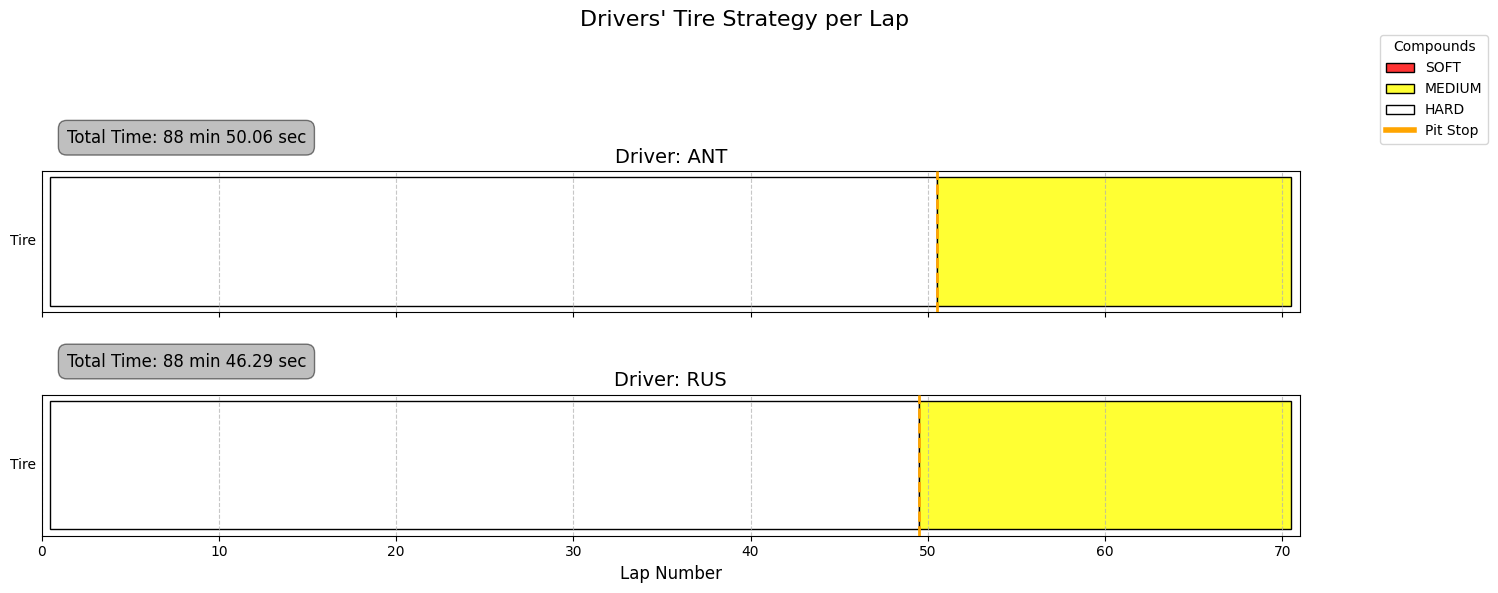

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Prepare data for plotting, including pit stop information
strategy_data = []
for d in drivers:
    for i in range(1, L + 1):
        current_compound = "N/A"
        current_age = "N/A"
        # Determine current compound and age from optimized x variable
        for c in compounds:
            for a in range(1, max_age):
                if x[d, i, c, a].X > 0.5:
                    current_compound = c
                    current_age = a
                    break
            if current_compound != "N/A":
                break

        # Check for pit stop *before* this lap (i.e., at the end of the previous lap)
        # A pit stop at the end of lap i-1 means a new tire for lap i
        pitted_before_this_lap = False
        if i > 1: # Pit stops only happen after lap 1
            if y[d, i-1].X > 0.5:
                pitted_before_this_lap = True

        strategy_data.append({'Driver': d, 'Lap': i, 'Compound': current_compound, 'Age': current_age, 'Pitted': pitted_before_this_lap})

df_strategy = pd.DataFrame(strategy_data)

# Define a consistent color palette for compounds
compound_colors = {'SOFT': '#FF3333', 'MEDIUM': '#FFFF33', 'HARD': '#FFFFFF'} # Brighter colors for clarity

# Create a figure with subplots for each driver
fig, axes = plt.subplots(len(drivers), 1, figsize=(15, len(drivers) * 3), sharex=True, sharey=True)
if len(drivers) == 1:
    axes = [axes] # Ensure axes is iterable even for a single driver

for idx, d in enumerate(drivers):
    ax = axes[idx]
    driver_df = df_strategy[df_strategy['Driver'] == d].copy()

    # Determine stints for each driver for plotting with barh
    stints_data = []
    current_compound = None
    stint_start_lap = 1

    for i in range(1, L + 1):
        compound_for_lap = driver_df[driver_df['Lap'] == i]['Compound'].iloc[0]

        if current_compound is None: # First lap of the driver's race
            current_compound = compound_for_lap
            stint_start_lap = i
        elif compound_for_lap != current_compound: # Compound changed, end of previous stint
            stints_data.append({'compound': current_compound, 'start': stint_start_lap, 'end': i - 1})
            current_compound = compound_for_lap
            stint_start_lap = i
    stints_data.append({'compound': current_compound, 'start': stint_start_lap, 'end': L}) # Add the last stint

    # Plot stints as horizontal bars
    for stint in stints_data:
        compound = stint['compound']
        start = stint['start']
        end = stint['end']
        # The y-coordinate is arbitrary, we use 0.5 for a single horizontal line per driver
        ax.barh(y=0.5, width=end - start + 1, left=start - 0.5, height=0.1, color=compound_colors.get(compound, 'gray'), edgecolor='black', linewidth=1)

    # Indicate pit stops visually with a vertical line
    pit_laps_indices = driver_df[driver_df['Pitted'] == True].index
    for pit_idx in pit_laps_indices:
        pit_lap_num = driver_df.loc[pit_idx, 'Lap']
        # The pit stop occurs at the end of the previous lap, so mark it between lap_num-1 and lap_num
        ax.axvline(x=pit_lap_num - 0.5, color='orange', linestyle='--', linewidth=2, zorder=3)

    # Calculate and display driver's total time
    driver_total_time = 0
    for i_lap in range(1, L + 1):
        current_lap_time = 0
        found_compound_for_lap = False
        for c_comp in compounds:
            for a_age in range(1, max_age):
                if x[d, i_lap, c_comp, a_age].X > 0.5:
                    current_lap_time = expected_lap_time[d][i_lap][c_comp][a_age]
                    found_compound_for_lap = True
                    break
            if found_compound_for_lap:
                break
        driver_total_time += current_lap_time
        if i_lap < L and y[d, i_lap].X > 0.5: # Pit stop after this lap
            driver_total_time += pit_stop_penalty

    minutes = int(driver_total_time // 60)
    seconds = round(driver_total_time % 60, 2)
    total_time_str = f"Total Time: {minutes} min {seconds} sec"

    ax.text(0.02, 1.3, total_time_str, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='grey', alpha=0.5))

    ax.set_title(f"Driver: {d}", fontsize=14)
    ax.set_yticks([]) # Remove y-ticks, as we are using a single line per driver
    ax.set_ylabel("Tire", rotation=0, ha='right', va='center') # Generic label
    ax.set_xlim(0, L + 1) # Set x-axis limits to cover all laps
    ax.set_xticks(np.arange(0, L + 1, 10)) # Adjust x-ticks for better readability
    ax.grid(axis='x', linestyle='--', alpha=0.7)

# Add a single legend for compounds and pit stops to the entire figure
handles = [plt.Rectangle((0,0),1,1, fc=color, ec="k") for comp, color in compound_colors.items()]
labels = list(compound_colors.keys())
handles.append(plt.Line2D([0], [0], color='orange', linestyle='-', linewidth=4))
labels.append('Pit Stop')

fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.0, 0.95), title="Compounds", fontsize=10)

fig.suptitle('Drivers\' Tire Strategy per Lap', fontsize=16)
plt.xlabel('Lap Number', fontsize=12)
plt.tight_layout(rect=[0, 0, 0.88, 0.9]) # Adjust layout to make space for suptitle and legends
plt.show()

### Exporting Raw and Cleaned Data

In [ ]:
#Cleaned Montreal race data
df_race.to_csv('cleaned_montreal_race_data.csv', index=False)

#Cleaned multi-race data
df_panel.to_csv('cleaned_panel_regression_data.csv', index=False)

import pandas as pd
import fastf1

#Raw Data
year = 2025
montreal_track = 'Montreal'
montreal_sessions = ['FP1', 'FP2', 'FP3', 'Q', 'R']

prior_races = [(2025, 'Australia'), (2025, 'China'), (2025, 'Japan'), (2025, 'Bahrain'), (2025, 'Saudi Arabia'), (2025, 'Miami'), (2025, 'Emilia Romagna'), (2025, 'Monaco')]

#All Montreal Sessions (Practice, Quali, Race)
for s_name in montreal_sessions:
    try:
        session = fastf1.get_session(year, montreal_track, s_name)
        session.load(telemetry=False, weather=False)
        raw_laps = session.laps

        filename = f'raw_{montreal_track}_{s_name}.csv'
        raw_laps.to_csv(filename, index=False)
        print(f"Exported: {filename}")
    except Exception as e:
        print(f"Failed to export {montreal_track} {s_name}: {e}")

# All Prior Races
for p_year, p_track in prior_races:
    try:
        session = fastf1.get_session(p_year, p_track, 'R')
        session.load(telemetry=False, weather=False)
        raw_laps = session.laps

        # Format the track name to remove spaces for cleaner filenames
        formatted_track = p_track.replace(' ', '_')
        filename = f'raw_{formatted_track}_Race.csv'

        raw_laps.to_csv(filename, index=False)
        print(f"Exported: {filename}")
    except Exception as e:
        print(f"Failed to export {p_year} {p_track}: {e}")

events      WARNING 	Correcting user input 'Montreal' to 'Canadian Grand Prix'
core           INFO 	Loading data for Canadian Grand Prix - Practice 1 [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Practice 1 [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Process

Exported: raw_Montreal_FP1.csv


core        WARNING 	No lap data for driver 16
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 16)
req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
events      WARNING 	Correcting user input 'Montreal' to 'Canadian Grand Prix'
core           INFO 	Loading data for Canadian Grand Prix - Practice 3 [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Practice 3 [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req     

Exported: raw_Montreal_FP2.csv


req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '4', '5', '6', '10', '12', '14', '16', '18', '22', '23', '27', '30', '31', '43', '44', '55', '63', '81', '87']
events      WARNING 	Correcting user input 'Montreal' to 'Canadian Grand Prix'
core           INFO 	Loading data for Canadian Grand Prix - Qualifying [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Canadian Grand Prix - Qualifying [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for se

...

Exported: raw_Miami_Race.csv


req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '4', '81', '44', '23', '16', '63', '55', '6', '22', '14', '27', '10', '30', '18', '43', '87', '5', '12', '31']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['1', '4', '81', '44', '23', '16', '63', '55', '6', '22', '14', '27', '10', '30', '18', '43', '87', '5', '12', '31']
core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.2]
INFO:fastf1.fastf1.core:Loading data for Monaco Grand Prix - Race [v3.8.2]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req         

Exported: raw_Emilia_Romagna_Race.csv


req            INFO 	Using cached data for race_control_messages
INFO:fastf1.fastf1.req:Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']
INFO:fastf1.fastf1.core:Finished loading data for 20 drivers: ['4', '16', '81', '1', '44', '6', '31', '30', '23', '55', '63', '87', '43', '5', '18', '27', '22', '12', '14', '10']


Exported: raw_Monaco_Race.csv
